# Voteview without the server — the client beneath the tool

`mcp.ipynb` calls `timeseries_source_data` over SSE. That tool is a thin wrapper
around a Python class, and this notebook uses the class directly: same database,
same rows, no server process.

Voteview has no per-request API to wrap, so there is no `clients/voteview.py`.
Its serving client is the generic `TimeSeriesSourceClient` — the same one that
serves CDC WONDER and NVSR. Nothing about it is Voteview-specific; `source` is
a column value, not a code path.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("../")
sys.path.append("../../")

from matplotlib import pyplot

from lib import config
from mcp_server.timeseries_source import TimeSeriesSourceClient, TimeSeriesSourceError

pyplot.style.use(config.glyfish_style)

## What is stored

`list_series` deliberately omits the observations column — it dominates the row,
and a listing does not need it.

In [2]:
async with TimeSeriesSourceClient() as store:
    refs = await store.list_series(source="voteview")

print(f"{len(refs)} Voteview series\n")
for r in refs:
    print(f"  {r.native_id:42s} {r.frequency:9s} "
          f"{r.observation_start}..{r.observation_end}")

8 Voteview series

  voteview/effective_parties/house           Biennial  1789-01-01..2025-01-01
  voteview/effective_parties/senate          Biennial  1789-01-01..2025-01-01
  voteview/median_gap/house                  Biennial  1857-01-01..2025-01-01
  voteview/median_gap/senate                 Biennial  1857-01-01..2025-01-01
  voteview/moderate_bloc/house               Biennial  1857-01-01..2025-01-01
  voteview/moderate_bloc/senate              Biennial  1857-01-01..2025-01-01
  voteview/party_predicts_position/house     Biennial  1789-01-01..2025-01-01
  voteview/party_predicts_position/senate    Biennial  1789-01-01..2025-01-01


## One series in full

`get_series` is where the observations arrive. The values are strings — the
storage contract keeps them as written rather than guessing a numeric type.

In [3]:
async with TimeSeriesSourceClient() as store:
    gap = await store.get_series("voteview", "voteview/median_gap/house")

print(gap.title)
print(f"  {gap.units} | {gap.observation_count} observations "
      f"| {gap.observation_start}..{gap.observation_end}")
print(f"  due {str(gap.expires_at)[:10]} | stale={gap.stale}")

first = gap.observations[0]
print(f"\n  first observation : {first!r}")
print(f"  value type        : {type(first.value).__name__}")

Distance between the party medians — US House
  dim1 | 85 observations | 1857-01-01..2025-01-01
  due 2026-10-13 | stale=False

  first observation : Observation(date='1857-01-01', value='0.6635', congress=35)
  value type        : str


## The same client, a different source

This is the point of the notebook. Swapping `source` reaches CDC WONDER through
the identical call — no per-source client, no branch.

In [4]:
async with TimeSeriesSourceClient() as store:
    everything = await store.list_series()
    wonder = await store.get_series(
        "cdc_wonder", "cdc/drug_overdose/wonder/national/age_adjusted")

by_source = {}
for r in everything:
    by_source[r.source] = by_source.get(r.source, 0) + 1
print("stored series by source:")
for source, n in sorted(by_source.items()):
    print(f"  {source:12s} {n:4d}")

print(f"\n{wonder.title}")
print(f"  {wonder.units} | {wonder.observation_count} observations")

stored series by source:
  cdc_nvsr      171
  cdc_wonder      9
  voteview        8

Drug overdose deaths, age-adjusted rate, United States
  deaths per 100,000 | 26 observations


## A miss is loud

An id that is not stored raises rather than returning empty, so a typo fails
where you made it instead of downstream.

In [5]:
async with TimeSeriesSourceClient() as store:
    try:
        await store.get_series("voteview", "voteview/median_gap/congress")
    except TimeSeriesSourceError as error:
        print(f"{type(error).__name__}: {error}")

TimeSeriesSourceError: no series voteview:voteview/median_gap/congress


## What is due for a refresh

`list_stale` is how the TTL is meant to be consumed — Voteview reduces from one
download, so all eight share a 30-day TTL and come due together rather than
sending eight requests for the same file at eight different times.

In [6]:
async with TimeSeriesSourceClient() as store:
    stale = await store.list_stale()
    refs = await store.list_series()

print(f"{len(stale)} of {len(refs)} stored series are stale\n")
due = sorted({(r.source, str(r.expires_at)[:10]) for r in refs})
for source, when in due:
    print(f"  {source:12s} next due {when}")

0 of 188 stored series are stale

  cdc_nvsr     next due 2027-09-13
  cdc_wonder   next due 2027-09-13
  voteview     next due 2026-10-13


## Plot

Nothing here parses a file. The series came from Postgres as typed models; the
only work left is casting the string values.

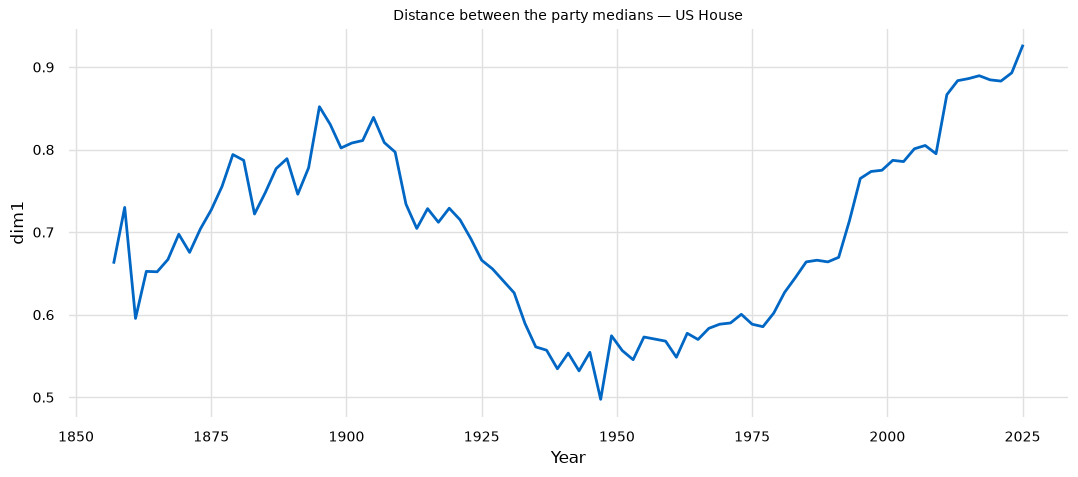

In [7]:
years = [int(o.date[:4]) for o in gap.observations]
values = [float(o.value) for o in gap.observations]

figure, axis = pyplot.subplots(figsize=(11, 5))
axis.plot(years, values, lw=2)
axis.set_title(gap.title, fontsize=10)
axis.set_xlabel("Year")
axis.set_ylabel(gap.units)
figure.tight_layout()

The reductions that produced these numbers — the party medians, the
representation gate, the effective-party count — are in
`utils/voteview_series.py`, and run as a build step, not at serve time. The
member panel they read never reaches this notebook or the server.